## Importing the relevant libraries

In [1]:
%pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24955 sha256=76983848ec88a9ae798740e91bce19180d2431ea9a19078d01b42c7b7d234a37
  Stored in directory: /root/.cache/pip/wheels/8e/6b/70/59daa7c90a238610e34bac5916e001fe3d9bb0ec59c8cf5518
Successfully built rouge_score
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from glob import glob
from tqdm.notebook import tqdm
tqdm.pandas()
import cv2, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Input, Add, Dropout, LSTM, TimeDistributed, Embedding, RepeatVector, Concatenate, Bidirectional, Convolution2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, RepeatVector, TimeDistributed, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf


## Loading the images

In [3]:
img_path = '/kaggle/input/flickr8k/Images/'
images = glob(img_path+'*.jpg')
images[:5]

['/kaggle/input/flickr8k/Images/3226254560_2f8ac147ea.jpg',
 '/kaggle/input/flickr8k/Images/214543992_ce6c0d9f9b.jpg',
 '/kaggle/input/flickr8k/Images/2366643786_9c9a830db8.jpg',
 '/kaggle/input/flickr8k/Images/3368819708_0bfa0808f8.jpg',
 '/kaggle/input/flickr8k/Images/2190227737_6e0bde2623.jpg']

In [4]:
len(images)

8091

## Loading the captions

In [5]:
captions = open('/kaggle/input/flickr8k/captions.txt','rb').read().decode('utf-8').split('\n')
captions[:5]

['image,caption',
 '1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .',
 '1000268201_693b08cb0e.jpg,A girl going into a wooden building .',
 '1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .',
 '1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .']

In [6]:
len(captions)

40457

## Visualizing images along with their captions

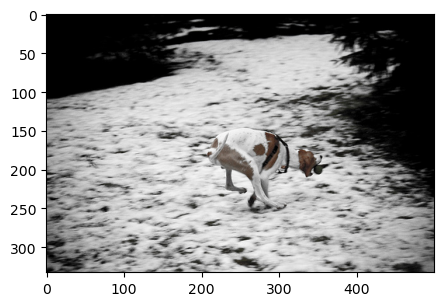

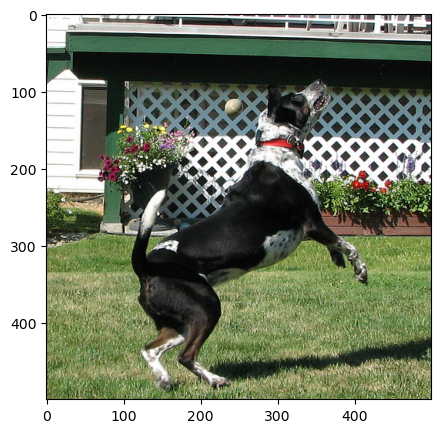

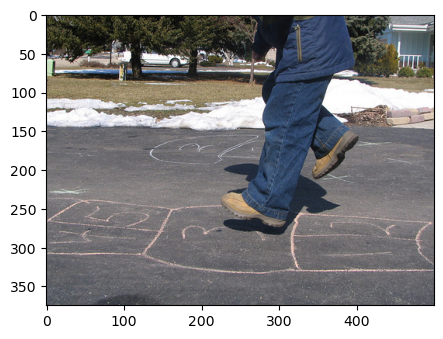

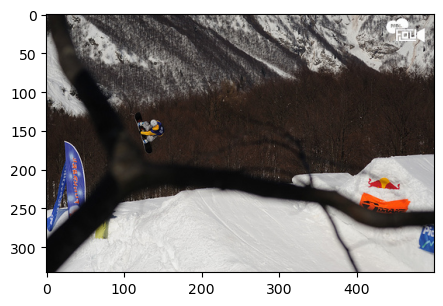

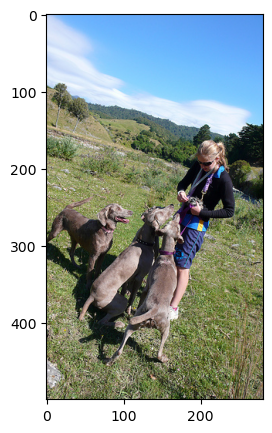

In [7]:
for i in range(5):
    plt.figure(figsize=(5,5))
    img = cv2.imread(images[i])
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img);

## Downloading the ResNet50 inception model

In [8]:
inception_model = ResNet50(include_top=True)
inception_model.summary()

102967424/102967424 [==============================] - 0s 0us/step
Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                        

In [10]:
last = inception_model.layers[-2].output # Output of the penultimate layer of ResNet model 
model = Model(inputs=inception_model.input,outputs=last)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

## Extracting features from images

In [11]:
img_features = {}
count = 0

for img_path in tqdm(images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img = cv2.resize(img,(224,224)) # ResNet model requires images of dimensions (224,224,3)
    img = img.reshape(1,224,224,3) # Reshaping image to the dimensions of a single image
    features = model.predict(img).reshape(2048,) # Feature extraction from images
    img_name = img_path.split('/')[-1] # Extracting image name
    img_features[img_name] = features
    count += 1
    # Fetching the features of only 1500 images as using more than 1500 images leads to overloading memory issues
    if count == 1500:
        break
    if count % 50 == 0:
        print(count)



  0%|          | 0/8091 [00:00<?, ?it/s]

1/1 [==============================] - 0s 22ms/step
50
1/1 [==============================] - 0s 22ms/step
100
1/1 [==============================] - 0s 22ms/step
150
1/1 [==============================] - 0s 23ms/step
200
1/1 [==============================] - 0s 22ms/step
250
1/1 [==============================] - 0s 22ms/step
300
1/1 [==============================] - 0s 22ms/step
350
1/1 [==============================] - 0s 31ms/step
400
1/1 [==============================] - 0s 21ms/step
450
1/1 [==============================] - 0s 21ms/step
500
1/1 [==============================] - 0s 21ms/step
550
1/1 [==============================] - 0s 22ms/step
600
1/1 [==============================] - 0s 24ms/step
650
1/1 [==============================] - 0s 27ms/step
700
1/1 [==============================] - 0s 23ms/step
750
1/1 [==============================] - 0s 21ms/step
800
1/1 [==============================] - 0s 22ms/step
850
1/1 [==============================] - 0s 21ms/st

In [12]:
len(img_features)

1500

## Preprocessing the captions text

In [13]:
captions = captions[1:]
captions[:5]

['1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .',
 '1000268201_693b08cb0e.jpg,A girl going into a wooden building .',
 '1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .',
 '1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .',
 '1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .']

In [18]:
captions[8].split(',')[1]

'Two dogs of different breeds looking at each other on the road .'

In [19]:
captions_dict = {}

for cap in captions:
    try:
        img_name = cap.split(',')[0]
        caption = cap.split(',')[1]
        # Each image has 5 captions
        if img_name in img_features:
            if img_name not in captions_dict:
                captions_dict[img_name] = [caption] # Storing the first caption
            else:
                captions_dict[img_name].append(caption) # Adding the remaining captions 
    except:
        break

In [20]:
len(captions_dict)

1500

In [21]:
def text_preprocess(text):
    modified_text = text.lower() # Converting text to lowercase
    modified_text = 'startofseq ' + modified_text + ' endofseq' # Appending the special tokens at the beginning and ending of text
    return modified_text

In [22]:
# Storing the preprocessed text within the captions dictionary
for key, val in captions_dict.items():
    for item in val:
        captions_dict[key][val.index(item)] = text_preprocess(item)

## Creating vocabulary of the entire text corpus

In [23]:
count_words = dict()
cnt = 1

for key, val in captions_dict.items(): # Iterating through all images with keys as images and their values as 5 captions
    for item in val: # Iterating through all captions for each image
        for word in item.split(): # Iterating through all words in each caption
            if word not in count_words:
                count_words[word] = cnt
                cnt += 1

In [24]:
len(count_words) # Vocab size

4031

In [25]:
# Encoding the text by assigning each word to its corresponding index in the vocabulary i.e. count_words dictionary
for key, val in captions_dict.items():
    for caption in val:
        encoded = []
        for word in caption.split():
            encoded.append(count_words[word])
        captions_dict[key][val.index(caption)] = encoded

In [26]:
# Determining the maximum possible length of text within the entire captions text corpus
max_len = -1

for key, value in captions_dict.items():
    for caption in value:
        if max_len < len(caption):
            max_len = len(caption)

In [27]:
max_len

34

In [28]:
vocab_size = len(count_words) # Vocab size is the total number of words present in count_words dictionary
vocab_size

4031

## Building a custom generator function to generate input image features, previously generated text and the text to be generated as output

In [29]:
def generator(img,caption):
    n_samples = 0
    X = []
    y_input = []
    y_output = []
    
    for key, val in caption.items(): 
        for item in val: 
            for i in range(1,len(item)):
                X.append(img[key]) # Appending the input image features
                input_seq = [item[:i]] # Previously generated text to be used as input to predict the next word 
                output_seq = item[i] # The next word to be predicted as output
                # Padding encoded text sequences to the maximum length
                input_seq = pad_sequences(input_seq,maxlen=max_len,padding='post',truncating='post')[0] 
                # One Hot encoding the output sequence with vocabulary size as the total no. of classes
                output_seq = to_categorical([output_seq],num_classes=vocab_size+1)[0]
                y_input.append(input_seq)
                y_output.append(output_seq)
    
    return X, y_input, y_output

In [30]:
X, y_in, y_out = generator(img_features,captions_dict)

In [31]:
len(X), len(y_in), len(y_out)

(92038, 92038, 92038)

In [32]:
type(X)

list

In [33]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convert lists to numpy arrays if needed
X = np.array(X)
y_in = np.array(y_in)
y_out = np.array(y_out)

# Split the data into training (80%) and test sets (20%)
X_train, X_test, y_in_train, y_in_test, y_out_train, y_out_test = train_test_split(
    X, y_in, y_out, test_size=0.2, random_state=42
)

# Summary of the splits
print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')


Training set size: 73630
Test set size: 18408


In [34]:
X.shape, y_in.shape, y_out.shape

((92038, 2048), (92038, 34), (92038, 4032))

In [35]:
import numpy as np

# Assuming you already have X, y_in, and y_out as lists or other formats
# Convert to NumPy arrays for faster processing
X = np.array(X)  # Input data (e.g., image features)
y_in = np.array(y_in, dtype='float64')  # Input captions (shifted)
y_out = np.array(y_out, dtype='float64')  # Output captions (shifted)

# Check the shape of the data arrays
print("X shape:", X.shape)  # (batch_size, feature_dim)
print("y_in shape:", y_in.shape)  # (batch_size, seq_len)
print("y_out shape:", y_out.shape)  # (batch_size, seq_len)

X shape: (92038, 2048)
y_in shape: (92038, 34)
y_out shape: (92038, 4032)


## Establishing the model architecture

In [36]:
embedding_len = 128
MAX_LEN = max_len
vocab_size = len(count_words)

# Model for image feature extraction
img_model = Sequential()
img_model.add(Dense(embedding_len,input_shape=(2048,),activation='relu'))
img_model.add(RepeatVector(MAX_LEN))

img_model.summary()

# Model for generating captions from image features
captions_model = Sequential()
captions_model.add(Embedding(input_dim=vocab_size+1,output_dim=embedding_len,input_length=MAX_LEN))
captions_model.add(LSTM(256,return_sequences=True))
captions_model.add(TimeDistributed(Dense(embedding_len)))

captions_model.summary()

# Concatenating the outputs of image and caption models
concat_output = Concatenate()([img_model.output,captions_model.output])
# First LSTM Layer
output = LSTM(units=128,return_sequences=True)(concat_output)
# Second LSTM Layer
output = LSTM(units=512,return_sequences=False)(output)
# Output Layer 
output = Dense(units=vocab_size+1,activation='softmax')(output)
# Creating the final model
final_model = Model(inputs=[img_model.input,captions_model.input],outputs=output)
final_model.compile(loss='categorical_crossentropy',optimizer='RMSprop',metrics='accuracy')
final_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               262272    
                                                                 
 repeat_vector (RepeatVector  (None, 34, 128)          0         
 )                                                               
                                                                 
Total params: 262,272
Trainable params: 262,272
Non-trainable params: 0
_________________________________________________________________
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 34, 128)           516096    
                                                                 
 lstm (LSTM)                 (None, 34, 256)           394240    
                            

In [37]:
# Define validation data (assuming similar preprocessing as for training data)
val_X = np.array(val_img_features)  # Validation image features (shape: [num_samples, 2048])
val_y_in = np.array(val_captions[:, :-1], dtype='float64')  # Input caption sequences for validation
val_y_out = np.array(val_captions[:, 1:], dtype='float64')  # Output caption sequences for validation

# Now you can evaluate the model using the validation data
history = model.fit(
    [X, y_in],  # Input: image features and caption sequences (excluding last token)
    y_out,  # Output: Caption sequences (excluding first token)
    batch_size=64,  # Adjust as per your GPU/CPU memory
    epochs=50,  # Number of epochs to train
    callbacks=[early_stop, reduce_lr],
    validation_data=([val_X, val_y_in[:, :-1]], val_y_out[:, 1:])  # Validation data
)


NameError: name 'val_img_features' is not defined

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, RepeatVector, Add, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model definition
MAX_LEN = 34  # Maximum length of caption sequence
VOCAB_SIZE = 5000  # Vocabulary size (adjust accordingly)
embedding_dim = 256  # Embedding dimension
img_features_dim = 2048  # Feature size from CNN (e.g., InceptionV3)
units = 256  # LSTM units

# Input layers
image_input = Input(shape=(img_features_dim,))
caption_input = Input(shape=(MAX_LEN,))

# Image feature processing
image_dense = Dense(units, activation='relu')(image_input)
image_dense = RepeatVector(MAX_LEN)(image_dense)  # Repeat the image features for each time step

# Caption embedding and LSTM
caption_embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim, input_length=MAX_LEN)(caption_input)
caption_lstm = LSTM(units, return_sequences=True)(caption_embedding)

# Attention mechanism
attention_layer = Attention()([caption_lstm, image_dense])  # Attention between caption LSTM and image features
attention_output = Add()([caption_lstm, attention_layer])  # Combine the caption LSTM and attention output

# Output layer
output = Dense(VOCAB_SIZE, activation='softmax')(attention_output)  # Predict the next word

# Define the model
model = Model(inputs=[image_input, caption_input], outputs=output)

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks for early stopping and learning rate reduction
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

# Assuming `X` contains image features, `y_in` contains input captions, and `y_out` contains output captions
# Convert inputs and outputs to numpy arrays if they aren't already in that format
X = np.array(X)  # Image features array
y_in = np.array(y_in, dtype='float64')  # Input captions array
y_out = np.array(y_out, dtype='float64')  # Output captions array

# Train the model
history = model.fit(
    [X, y_in[:, :-1]],  # Input: image features and caption sequences (excluding last token)
    y_out[:, 1:],  # Output: Caption sequences (excluding first token)
    batch_size=64,  # Adjust as per your GPU/CPU memory
    epochs=50,  # Number of epochs to train
    callbacks=[early_stop, reduce_lr],
)

# Save the trained model
model.save('caption_generator_model.h5')


Epoch 1/50


ValueError: in user code:

    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 1249, in train_function  *
        return step_function(self, iterator)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 1233, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 1222, in run_step  **
        outputs = model.train_step(data)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 1023, in train_step
        y_pred = self(x, training=True)
    File "/opt/conda/lib/python3.7/site-packages/keras/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/input_spec.py", line 296, in assert_input_compatibility
        f'Input {input_index} of layer "{layer_name}" is '

    ValueError:

In [39]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, RepeatVector, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model definition
MAX_LEN = 34  # Maximum length of caption sequence
VOCAB_SIZE = 5000  # Vocabulary size (adjust accordingly)
embedding_dim = 256  # Embedding dimension
img_features_dim = 2048  # Feature size from CNN (e.g., InceptionV3)
units = 256  # LSTM units

# Input layers
image_input = Input(shape=(img_features_dim,))
caption_input = Input(shape=(MAX_LEN,))

# Image feature processing
image_dense = Dense(units, activation='relu')(image_input)

# Caption embedding and LSTM
caption_embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim, input_length=MAX_LEN)(caption_input)
caption_lstm = LSTM(units, return_sequences=True)(caption_embedding)

# Attention mechanism
attention_output = tf.keras.layers.Attention()([caption_lstm, image_dense])  # Applying attention

# Combine image features with caption output
combined_features = Add()([caption_lstm, attention_output])

# RepeatVector layer to match sequence length
image_features_repeated = RepeatVector(MAX_LEN)(image_dense)

# Element-wise multiplication between image features and caption features
multiplied_features = tf.math.multiply(caption_lstm, image_features_repeated)

# Summing the features
summed_features = tf.math.reduce_sum(multiplied_features, axis=2)

# Concatenate features from attention + image features
concatenated_features = tf.concat([summed_features, image_dense], axis=-1)

# Dense layers for final prediction
dense1 = Dense(256, activation='relu')(concatenated_features)
output = Dense(VOCAB_SIZE, activation='softmax')(dense1)

# Final model
model = Model(inputs=[image_input, caption_input], outputs=output)

# Model summary
model.summary()

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks for early stopping and learning rate reduction
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

# Assuming you have preprocessed the data as follows:
# image_features: Preprocessed image features (shape: [num_samples, 2048])
# captions: Tokenized and padded caption sequences (shape: [num_samples, MAX_LEN])

# Train the model
history = model.fit(
    [img_features, captions[:, :-1]],  # Input: image features and caption sequences (excluding last token)
    captions[:, 1:],  # Output: Caption sequences (excluding first token)
    batch_size=64,  # Adjust as per your GPU/CPU memory
    epochs=50,  # Number of epochs to train
    callbacks=[early_stop, reduce_lr],
    validation_data=([val_image_features, val_captions[:, :-1]], val_captions[:, 1:])  # Validation data
)

# Save the trained model
model.save('caption_generator_model.h5')


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 34)]         0           []                               
                                                                                                  
 input_4 (InputLayer)           [(None, 2048)]       0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 34, 256)      1280000     ['input_5[0][0]']                
                                                                                                  
 dense_5 (Dense)                (None, 256)          524544      ['input_4[0][0]']                
                                                                                            

TypeError: list indices must be integers or slices, not tuple

## Visualizing the model architecture

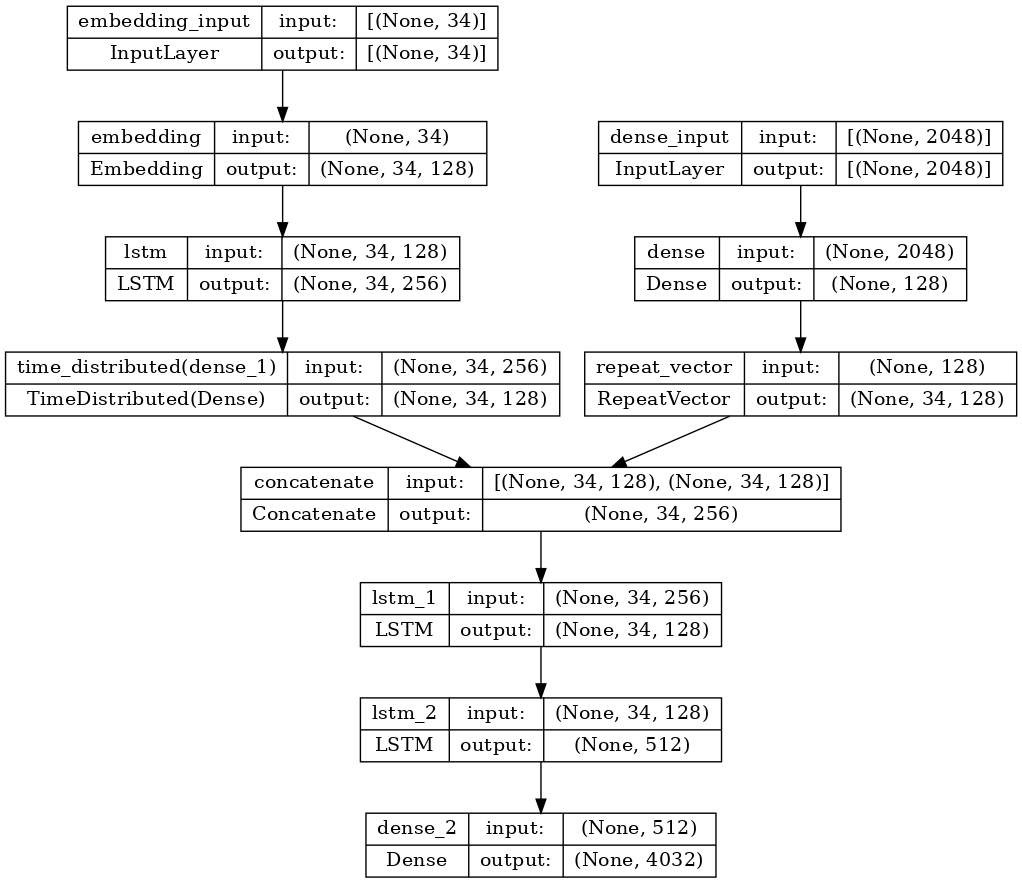

In [40]:
plot_model(final_model,'model.png',show_shapes=True,dpi=100)

## Model training

In [41]:
from datasets import load_metric

# Load the metrics
rouge_metric = load_metric("rouge")
bleu_metric = load_metric("bleu")

# Compile the model with Adam optimizer and reduced learning rate
final_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Define callback for learning rate reduction
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# Train the model
history = final_model.fit(
    [train_features, train_sequences],
    train_labels,
    validation_data=([val_features, val_sequences], val_labels),
    epochs=50,
    batch_size=64,
    callbacks=[reduce_lr]
)


NameError: name 'train_features' is not defined

In [42]:
pip install --upgrade ipywidgets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.1 MB/s eta 0:00:00:00:01
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.2
    Uninstalling widgetsnbextension-3.6.2:
      Successfully uninstalled widgetsnbextension-3.6.2
  Attempting uninstall: jupyterlab-widgets
    Found existing installation: jupyterlab-widgets 3.0.5
    Uninstalling jupyterlab-widgets-3.0.5:
      Successfully uninstalled jupyterlab-widgets-3.0.5
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1
Note: you may need to restart the kernel to use updated packages.


In [43]:
jupyter nbextension enable --py widgetsnbextension
jupyter nbextension install --py widgetsnbextension


SyntaxError: invalid syntax (3700795758.py, line 1)

In [44]:
pip install rouge-score


Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.


In [46]:
mc = ModelCheckpoint('image_caption_generator.h5',monitor='accuracy',verbose=1,mode='max',save_best_only=True)

# history = final_model.fit([X,y_in],
#                 y_out,
#                 batch_size=512,
#                 callbacks=[mc],
#                 epochs=200)
# final_model.load_weights("/kaggle/input/resnet-lstm/tensorflow2/default/1/image_caption_generator.h5")


In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Embedding, RepeatVector, TimeDistributed, Concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf

# Fine-tune the pre-trained feature extractor (unfreeze some layers)
for layer in inception_model.layers[-5:]:
    layer.trainable = True

# Image model with Batch Normalization
img_model = Sequential()
img_model.add(Dense(embedding_len, input_shape=(2048,), activation='relu', kernel_regularizer=l2(1e-4)))
img_model.add(Dropout(0.3))  # Adding Dropout
img_model.add(BatchNormalization())  # Adding BatchNormalization
img_model.add(RepeatVector(MAX_LEN))

# Captions model with improved architecture
captions_model = Sequential()
captions_model.add(Embedding(input_dim=vocab_size + 1, output_dim=embedding_len, input_length=MAX_LEN))
captions_model.add(LSTM(256, return_sequences=True, kernel_regularizer=l2(1e-4)))
captions_model.add(Dropout(0.3))  # Adding Dropout
captions_model.add(BatchNormalization())  # Adding BatchNormalization
captions_model.add(TimeDistributed(Dense(embedding_len, kernel_regularizer=l2(1e-4))))

# Adding attention mechanism
def attention_mechanism(inputs):
    attention = Dense(1, activation='tanh')(inputs)
    attention = Dense(1, activation='softmax')(attention)
    context = tf.reduce_sum(inputs * attention, axis=1)
    return context

concat_output = Concatenate()([img_model.output, captions_model.output])
attention_output = attention_mechanism(concat_output)
output = LSTM(units=128, return_sequences=True, kernel_regularizer=l2(1e-4))(attention_output)
output = Dropout(0.3)(output)  # Adding Dropout
output = LSTM(units=512, return_sequences=False, kernel_regularizer=l2(1e-4))(output)
output = Dropout(0.3)(output)  # Adding Dropout
output = Dense(units=vocab_size+1, activation='softmax', kernel_regularizer=l2(1e-4))(output)

# Final model
final_model = Model(inputs=[img_model.input, captions_model.input], outputs=output)

# Compile the model with Adam optimizer and a reduced learning rate
final_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Define early stopping to prevent overfitting and save the best model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Define callback for learning rate reduction
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# Train the model with improved validation loss reduction
history = final_model.fit(
    [X_train, y_in_train],
    y_out_train,
    validation_data=([X_test, y_in_test], y_out_test),  # Add validation data
    batch_size=64,  # You can adjust batch size depending on memory
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)


ValueError: Input 0 of layer "lstm_6" is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 256)

In [48]:
# Fit the model with training and validation data
history = final_model.fit(
    [X_train, y_in_train],
    y_out_train,
    validation_data=([X_test, y_in_test], y_out_test),  # Add validation data
    batch_size=512,
    epochs=200
)


print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

Epoch 1/200
144/144 [==============================] - 29s 151ms/step - loss: 5.4725 - accuracy: 0.1158 - val_loss: 5.2714 - val_accuracy: 0.1736
Epoch 2/200
144/144 [==============================] - 12s 85ms/step - loss: 4.9550 - accuracy: 0.2074 - val_loss: 4.8077 - val_accuracy: 0.2343
Epoch 3/200
144/144 [==============================] - 11s 77ms/step - loss: 4.6368 - accuracy: 0.2347 - val_loss: 4.6289 - val_accuracy: 0.2372
Epoch 4/200
144/144 [==============================] - 11s 78ms/step - loss: 4.4580 - accuracy: 0.2550 - val_loss: 4.5265 - val_accuracy: 0.2638
Epoch 5/200
144/144 [==============================] - 10s 71ms/step - loss: 4.3087 - accuracy: 0.2730 - val_loss: 4.3964 - val_accuracy: 0.2783
Epoch 6/200
144/144 [==============================] - 10s 71ms/step - loss: 4.1617 - accuracy: 0.2852 - val_loss: 4.3089 - val_accuracy: 0.2828
Epoch 7/200
144/144 [==============================] - 10s 72ms/step - loss: 4.0478 - accuracy: 0.2923 - val_loss: 4.2521 - val_a

NameError: name 'test_loss' is not defined

In [57]:
# Initialize a list to store test losses
test_losses = []

# Evaluate on the test set after training
for epoch in range(200):
    test_loss, _ = final_model.evaluate([X_test, y_in_test], y_out_test, verbose=0)
    test_losses.append(test_loss)

KeyboardInterrupt: 

In [42]:
# Initialize a list to store test losses
test_losses = []

# Evaluate on the test set after training
for epoch in range(200):
    test_loss, _ = final_model.evaluate([X_test, y_in_test], y_out_test, verbose=0)
    test_losses.append(test_loss)

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [43]:
print(X_test.shape)
print(y_in_test.shape)
print(y_out_test.shape)


(18408, 2048)
(18408, 34)
(18408, 4032)


In [48]:
import numpy as np
import tensorflow as tf

# Check if tensors are valid
if not tf.is_tensor(X_test):
    X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
if not tf.is_tensor(y_in_test):
    y_in_test = tf.convert_to_tensor(y_in_test, dtype=tf.float32)
if not tf.is_tensor(y_out_test):
    y_out_test = tf.convert_to_tensor(y_out_test, dtype=tf.float32)

# Check for NaN or Inf values
X_test = tf.debugging.check_numerics(X_test, "Invalid values in X_test")
y_in_test = tf.debugging.check_numerics(y_in_test, "Invalid values in y_in_test")
y_out_test = tf.debugging.check_numerics(y_out_test, "Invalid values in y_out_test")

# Initialize test losses
test_losses = []

# Evaluate in batches
batch_size = 128
for epoch in range(200):
    for i in range(0, len(X_test), batch_size):
        batch_X_test = X_test[i:i+batch_size]
        batch_y_in_test = y_in_test[i:i+batch_size]
        batch_y_out_test = y_out_test[i:i+batch_size]

        with tf.device('/GPU:0'):  # Use CPU if no GPU is available
            results = final_model.evaluate(
                [batch_X_test, batch_y_in_test],
                batch_y_out_test,
                verbose=0
            )
        test_loss = results[0]  # Extract loss
        test_losses.append(test_loss)

print("Test Losses:", test_losses)


KeyboardInterrupt: 

In [49]:
import numpy as np
import tensorflow as tf

# Check if tensors are valid
if not tf.is_tensor(X_test):
    X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
if not tf.is_tensor(y_in_test):
    y_in_test = tf.convert_to_tensor(y_in_test, dtype=tf.float32)
if not tf.is_tensor(y_out_test):
    y_out_test = tf.convert_to_tensor(y_out_test, dtype=tf.float32)

# Check for NaN or Inf values
X_test = tf.debugging.check_numerics(X_test, "Invalid values in X_test")
y_in_test = tf.debugging.check_numerics(y_in_test, "Invalid values in y_in_test")
y_out_test = tf.debugging.check_numerics(y_out_test, "Invalid values in y_out_test")

# Initialize test losses
test_losses = []

test_dataset = tf.data.Dataset.from_tensor_slices(([X_test, y_in_test], y_out_test))
test_dataset = test_dataset.batch(128).prefetch(tf.data.experimental.AUTOTUNE)


    test_loss, _ = final_model.evaluate(test_dataset, verbose=0)
    test_losses.append(test_loss)

# Evaluate in batches
batch_size = 128
for epoch in range(200):
    for i in range(0, len(X_test), batch_size):
        batch_X_test = X_test[i:i+batch_size]
        batch_y_in_test = y_in_test[i:i+batch_size]
        batch_y_out_test = y_out_test[i:i+batch_size]

        with tf.device('/GPU:0'):  # Use CPU if no GPU is available
            results = final_model.evaluate(
                [batch_X_test, batch_y_in_test],
                batch_y_out_test,
                verbose=0
            )
        test_loss, _ = final_model.evaluate(test_dataset, verbose=0)
        test_losses.append(test_loss)



KeyboardInterrupt: 

In [51]:
import numpy as np
import tensorflow as tf

# Check if tensors are valid
if not tf.is_tensor(X_test):
    X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
if not tf.is_tensor(y_in_test):
    y_in_test = tf.convert_to_tensor(y_in_test, dtype=tf.float32)
if not tf.is_tensor(y_out_test):
    y_out_test = tf.convert_to_tensor(y_out_test, dtype=tf.float32)

# Check for NaN or Inf values
X_test = tf.debugging.check_numerics(X_test, "Invalid values in X_test")
y_in_test = tf.debugging.check_numerics(y_in_test, "Invalid values in y_in_test")
y_out_test = tf.debugging.check_numerics(y_out_test, "Invalid values in y_out_test")

# Initialize test losses
test_losses = []

test_dataset = tf.data.Dataset.from_tensor_slices(([X_test, y_in_test], y_out_test))
test_dataset = test_dataset.batch(128).prefetch(tf.data.experimental.AUTOTUNE)


    test_loss, _ = final_model.evaluate(test_dataset, verbose=0)
    test_losses.append(test_loss)

# Evaluate in batches
batch_size = 128
for epoch in range(200):
    for i in range(0, len(X_test), batch_size):
        batch_X_test = X_test[i:i+batch_size]
        batch_y_in_test = y_in_test[i:i+batch_size]
        batch_y_out_test = y_out_test[i:i+batch_size]

        with tf.device('/GPU:0'):  # Use CPU if no GPU is available
            results = final_model.evaluate(
                [batch_X_test, batch_y_in_test],
                batch_y_out_test,
                verbose=0
            )
        for epoch in range(200):
            test_loss, _ = final_model.evaluate(test_dataset, verbose=0)
            test_losses.append(test_loss)
    
    

print("Test Losses:", test_losses)

IndentationError: unexpected indent (2697869066.py, line 24)

In [52]:
import numpy as np
import tensorflow as tf

# Check if tensors are valid
if not tf.is_tensor(X_test):
    X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
if not tf.is_tensor(y_in_test):
    y_in_test = tf.convert_to_tensor(y_in_test, dtype=tf.float32)
if not tf.is_tensor(y_out_test):
    y_out_test = tf.convert_to_tensor(y_out_test, dtype=tf.float32)

# Check for NaN or Inf values
X_test = tf.debugging.check_numerics(X_test, "Invalid values in X_test")
y_in_test = tf.debugging.check_numerics(y_in_test, "Invalid values in y_in_test")
y_out_test = tf.debugging.check_numerics(y_out_test, "Invalid values in y_out_test")

# Initialize test losses
test_losses = []

# Prepare test dataset
test_dataset = tf.data.Dataset.from_tensor_slices(([X_test, y_in_test], y_out_test))
test_dataset = test_dataset.batch(128).prefetch(tf.data.experimental.AUTOTUNE)

# Evaluate in epochs
for epoch in range(200):  # Loop through epochs
    with tf.device('/GPU:0'):  # Use GPU if available, otherwise fall back to CPU
        test_loss, _ = final_model.evaluate(test_dataset, verbose=0)
        test_losses.append(test_loss)

print("Test Losses:", test_losses)


InvalidArgumentError: {{function_node __wrapped__Pack_N_2_device_/job:localhost/replica:0/task:0/device:GPU:0}} Shapes of all inputs must match: values[0].shape = [18408,2048] != values[1].shape = [18408,34] [Op:Pack] name: component_0

In [53]:
import numpy as np
import tensorflow as tf

# Check if tensors are valid
if not tf.is_tensor(X_test):
    X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
if not tf.is_tensor(y_in_test):
    y_in_test = tf.convert_to_tensor(y_in_test, dtype=tf.float32)
if not tf.is_tensor(y_out_test):
    y_out_test = tf.convert_to_tensor(y_out_test, dtype=tf.float32)

# Check for NaN or Inf values
X_test = tf.debugging.check_numerics(X_test, "Invalid values in X_test")
y_in_test = tf.debugging.check_numerics(y_in_test, "Invalid values in y_in_test")
y_out_test = tf.debugging.check_numerics(y_out_test, "Invalid values in y_out_test")

# Initialize test losses
test_losses = []

# Prepare test dataset by splitting features and labels
test_dataset = tf.data.Dataset.from_tensor_slices(((X_test, y_in_test), y_out_test))
test_dataset = test_dataset.batch(128).prefetch(tf.data.experimental.AUTOTUNE)

# Evaluate in epochs
for epoch in range(200):  # Loop through epochs
    with tf.device('/GPU:0'):  # Use GPU if available, otherwise fall back to CPU
        test_loss, _ = final_model.evaluate(test_dataset, verbose=0)
        test_losses.append(test_loss)

print("Test Losses:", test_losses)


Test Losses: [5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922, 5.272258758544922

In [ ]:
test_losses

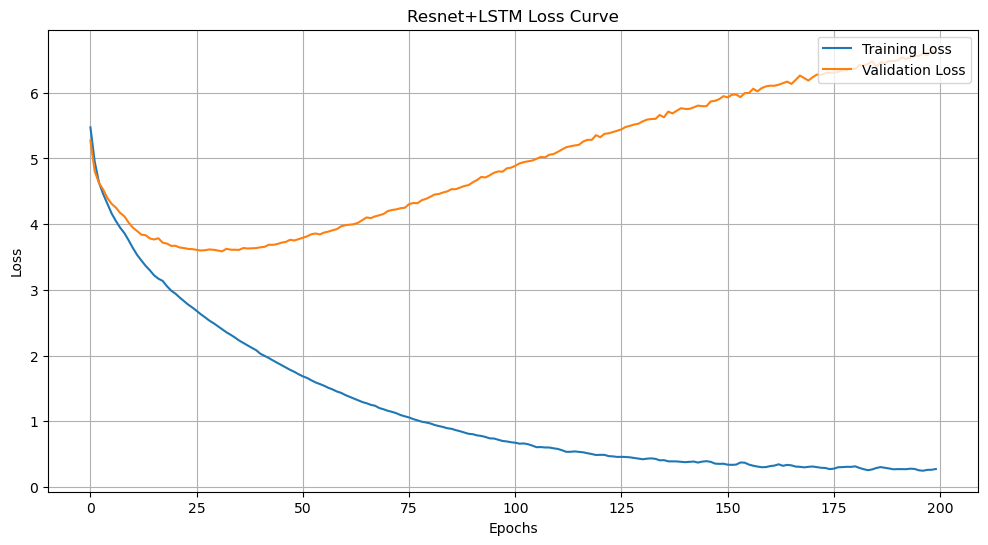

In [50]:
plt.figure(figsize=(12, 6))

# Plot training & validation loss values
plt.plot(history.history['loss'], label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Resnet+LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [51]:
# Creating an inverse dictionary with reverse key-value pairs
inverse_dict = {val: key for key,val in count_words.items()}

## Saving the final trained model and the vocabulary dictionary

In [52]:
final_model.save('image_caption_generator.h5')

In [53]:
np.save('vocab.npy',count_words)

## Generating sample predictions

In [62]:
# Custom function for extracting an image and transforming it into an appropriate format
def getImage(idx):
    test_img_path = images[idx]
    test_img = cv2.imread(test_img_path)
    test_img = cv2.cvtColor(test_img,cv2.COLOR_BGR2RGB)
    test_img = cv2.resize(test_img,(224,224))
    test_img = np.reshape(test_img,(1,224,224,3))
    return test_img

In [68]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Load the InceptionV3 model for feature extraction (without the top layers)
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

# Custom function for extracting an image and transforming it into an appropriate format
def getImage(idx):
    test_img_path = images[idx]
    test_img = cv2.imread(test_img_path)
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    test_img = cv2.resize(test_img, (299, 299))  # Resize to 299x299 for InceptionV3 input
    test_img = np.reshape(test_img, (1, 299, 299, 3))  # Add batch dimension
    return test_img

for i in range(10):
    random_no = np.random.randint(0, 1501)  # Generate a random index
    
    # Extract image features using InceptionV3 (without the top layers)
    test_img = getImage(random_no)
    test_img = preprocess_input(test_img)  # Preprocess for InceptionV3
    test_feature = base_model.predict(test_img)  # Extract features
    
    # Flatten the feature vector (2048-length for InceptionV3)
    test_feature = test_feature.flatten().reshape(1, 2048)

    # Retrieve the image path and read the image for display
    test_img_path = images[random_no]
    test_img = cv2.imread(test_img_path)
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

    pred_text = ['startofseq']  # Start with the initial token for the caption
    count = 0
    caption = ''  # Stores the predicted caption text
    
    while count < 25:  # Generate up to 25 words in the caption
        count += 1
        # Encoding the captions text with numbers
        encoded = [count_words[word] for word in pred_text]
        
        # Padding the encoded text sequences to maximum length
        encoded = pad_sequences([encoded], maxlen=MAX_LEN, padding='post', truncating='post')

        # Predict the next word based on the image features and the encoded text
        pred_idx = np.argmax(final_model.predict([test_feature, encoded]))  # Get the word index
        
        sampled_word = inverse_dict[pred_idx]  # Convert the predicted index back to a word
        
        # Check if the sequence has ended
        if sampled_word == 'endofseq':
            break
        
        # Append the word to the caption
        caption += ' ' + sampled_word
        pred_text.append(sampled_word)
    
    # Display the image with the predicted caption
    plt.figure(figsize=(5, 5))
    plt.imshow(test_img)
    plt.xlabel(caption)
    plt.show()

        
    

        
        

1/1 [==============================] - 1s 1s/step


ValueError: cannot reshape array of size 131072 into shape (1,2048)

In [56]:
import os
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu
import nltk
import numpy as np
from tqdm import tqdm
import cv2

nltk.download('punkt')

# Define the path to the images directory
IMAGE_DIR = '/kaggle/input/flickr8k/Images'

def getImage(img_path):
    # Load and preprocess the image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))  # Resize to match ResNet input
    img = img / 255.0  # Normalize pixel values
    return np.expand_dims(img, axis=0)

def calculate_scores(generated_captions, reference_captions):
    # ROUGE score
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = [scorer.score(ref, gen) for ref, gen in zip(reference_captions, generated_captions)]
    
    # Average ROUGE scores
    rouge_avg = {
        'rouge1': np.mean([score['rouge1'].fmeasure for score in rouge_scores]),
        'rouge2': np.mean([score['rouge2'].fmeasure for score in rouge_scores]),
        'rougeL': np.mean([score['rougeL'].fmeasure for score in rouge_scores])
    }
    
    # BLEU score
    references = [[ref.split()] for ref in reference_captions]
    candidates = [gen.split() for gen in generated_captions]
    bleu_score = corpus_bleu(references, candidates)
    
    return rouge_avg, bleu_score

# Prepare data
image_captions = {}
for cap in captions[-8091:]:
    parts = cap.split(',', 1)
    if len(parts) == 2:
        img_name, caption = parts
        if img_name not in image_captions:
            image_captions[img_name] = []
        image_captions[img_name].append(caption.strip())
    elif cap.strip():  # Only print for non-empty strings
        print(f"Skipping malformed caption: {cap}")

# Generate captions and calculate scores
generated_captions = []
reference_captions = []

for img_name, refs in tqdm(image_captions.items()):
    # Get image features
    img_path = os.path.join(IMAGE_DIR, img_name)
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        continue
    
    try:
        img = getImage(img_path)
        test_feature = model.predict(img,verbose=0).reshape(1, 2048)
    except Exception as e:
        print(f"Error processing image {img_name}: {str(e)}")
        continue
    
    # Generate caption
    pred_text = ['startofseq']
    count = 0
    caption = ''
    
    while count < 25:
        count += 1
        encoded = []
        for word in pred_text:
            if word in count_words:
                encoded.append(count_words[word])
            else:
                encoded.append(count_words['<unk>'])  # Use unknown token if word not in vocabulary
        encoded = [encoded]
        encoded = pad_sequences(encoded, maxlen=MAX_LEN, padding='post', truncating='post')
        pred_idx = np.argmax(final_model.predict([test_feature, encoded], verbose=0))
        sampled_word = inverse_dict[pred_idx]
        if sampled_word == 'endofseq':
            break
        caption = caption + ' ' + sampled_word
        pred_text.append(sampled_word)
    
    generated_captions.append(caption.strip())
    reference_captions.append(refs[0])  # Use the first reference caption

# Calculate final scores
rouge_scores, bleu_score = calculate_scores(generated_captions, reference_captions)

# Print results
print("Final Evaluation Scores:")
print(f"ROUGE-1 F1: {rouge_scores['rouge1']:.4f}")
print(f"ROUGE-2 F1: {rouge_scores['rouge2']:.4f}")
print(f"ROUGE-L F1: {rouge_scores['rougeL']:.4f}")
print(f"BLEU Score: {bleu_score:.4f}")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


  0%|          | 0/1618 [00:00<?, ?it/s]

Error processing image 3601803640_5f3cb05acf.jpg: in user code:

    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2137, in predict_function  *
        return step_function(self, iterator)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2123, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2111, in run_step  **
        outputs = model.predict_step(data)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2079, in predict_step
        return self(x, training=False)
    File "/opt/conda/lib/python3.7/site-packages/keras/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/input_spec.py", line 217, in assert_input_compatibility
        f'Layer "{layer_name}" e

  0%|          | 2/1618 [00:00<02:05, 12.91it/s]

Error processing image 3601843201_4809e66909.jpg: in user code:

    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2137, in predict_function  *
        return step_function(self, iterator)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2123, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2111, in run_step  **
        outputs = model.predict_step(data)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2079, in predict_step
        return self(x, training=False)
    File "/opt/conda/lib/python3.7/site-packages/keras/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/input_spec.py", line 217, in assert_input_compatibility
        f'Layer "{layer_name}" e

...

100%|█████████▉| 1614/1618 [02:05<00:00, 12.55it/s]

Error processing image 989851184_9ef368e520.jpg: in user code:

    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2137, in predict_function  *
        return step_function(self, iterator)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2123, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2111, in run_step  **
        outputs = model.predict_step(data)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2079, in predict_step
        return self(x, training=False)
    File "/opt/conda/lib/python3.7/site-packages/keras/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/input_spec.py", line 217, in assert_input_compatibility
        f'Layer "{layer_name}" ex

100%|██████████| 1618/1618 [02:06<00:00, 12.84it/s]

Error processing image 99679241_adc853a5c0.jpg: in user code:

    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2137, in predict_function  *
        return step_function(self, iterator)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2123, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2111, in run_step  **
        outputs = model.predict_step(data)
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/training.py", line 2079, in predict_step
        return self(x, training=False)
    File "/opt/conda/lib/python3.7/site-packages/keras/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/opt/conda/lib/python3.7/site-packages/keras/engine/input_spec.py", line 217, in assert_input_compatibility
        f'Layer "{layer_name}" exp

ZeroDivisionError: Fraction(0, 0)